In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, roc_auc_score, classification_report
from sklearn.feature_selection import SelectKBest, mutual_info_classif

In [2]:
merged_dataset = pd.read_parquet("final_merged_dataset.parquet")
merged_dataset = merged_dataset.sort_values("datetime_hour").reset_index(drop=True)

In [3]:
TARGET = "alarm_active"

In [4]:
excl_from_features = [
    "datetime_hour", "alarm_active", "alarm_minutes_in_hour",
    "region_key", "day_datetime", "date", "hour_datetime",
    "day_sunrise", "day_sunset", "region_id", "alarm_lag_1"
]

feature_cols = [c for c in merged_dataset.columns if c not in excl_from_features]
X = merged_dataset[feature_cols].select_dtypes(include=["number", "bool"]).copy()
y = merged_dataset[TARGET]

In [5]:
split = int(len(merged_dataset) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

In [6]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [7]:
y_pred_raw = model.predict(X_test_scaled)
y_pred = (y_pred_raw >= 0.5).astype(int)

In [8]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"\nMAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.4f}")

print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_raw):.4f}")
print(classification_report(y_test, y_pred, target_names=["No alarm", "Alarm"]))


MAE: 0.15
RMSE: 0.39
R²: 0.2954
ROC-AUC: 0.9194
              precision    recall  f1-score   support

    No alarm       0.86      0.94      0.90    118084
       Alarm       0.83      0.65      0.73     52624

    accuracy                           0.85    170708
   macro avg       0.84      0.79      0.81    170708
weighted avg       0.85      0.85      0.84    170708



In [9]:
BLUE_MAIN = "#2F6DB3"
RED_ACCENT = "#D1495B"

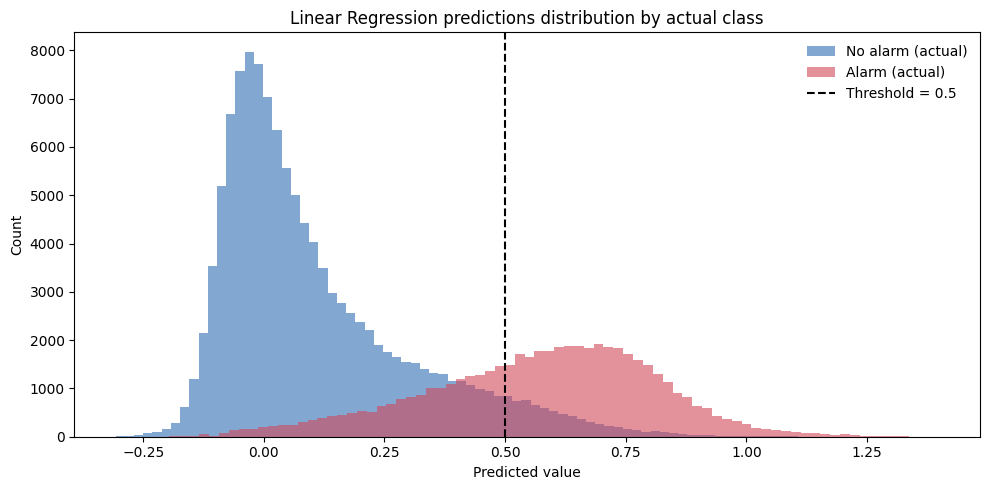

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(y_pred_raw[y_test == 0], bins=80, alpha=0.6, color=BLUE_MAIN, label="No alarm (actual)")
ax.hist(y_pred_raw[y_test == 1], bins=80, alpha=0.6, color=RED_ACCENT, label="Alarm (actual)")
ax.axvline(0.5, color="black", linestyle="--", linewidth=1.5, label="Threshold = 0.5")
ax.set_xlabel("Predicted value")
ax.set_ylabel("Count")
ax.set_title("Linear Regression predictions distribution by actual class")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

In [11]:
print(y_pred_raw.min()) 
print(y_pred_raw.max())  

-0.30725067632073255
1.3987434996732455


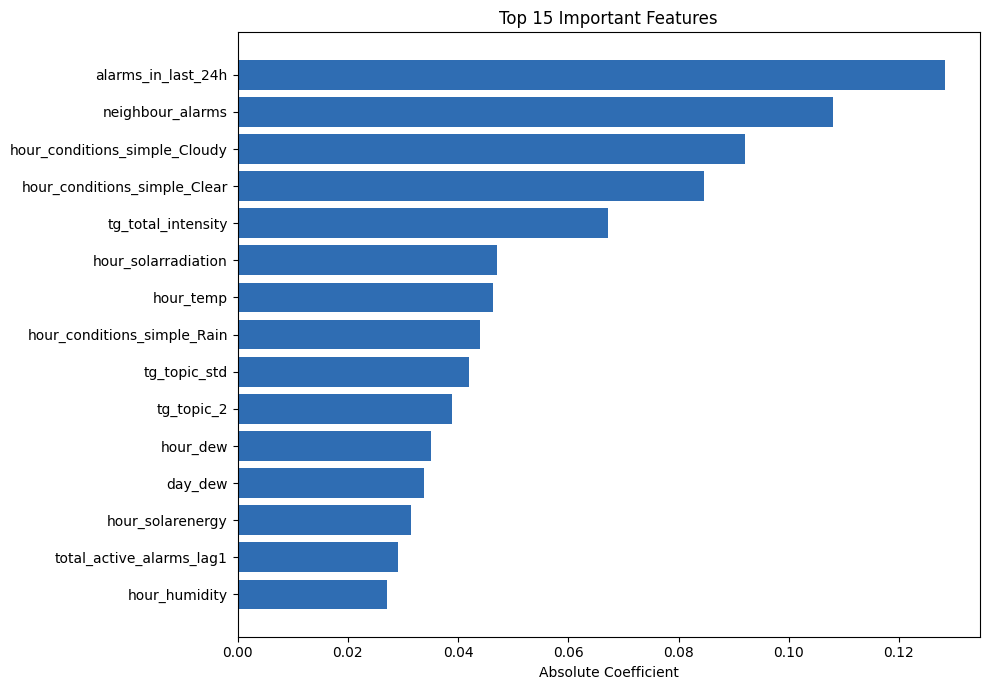

In [12]:
feature_importance = pd.DataFrame({
    "feature": X.columns.tolist(),
    "coefficient": np.abs(model.coef_)
}).sort_values("coefficient", ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
top15 = feature_importance.head(15)
ax.barh(top15["feature"], top15["coefficient"], color=BLUE_MAIN)
ax.set_xlabel("Absolute Coefficient")
ax.set_title("Top 15 Important Features")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [13]:
feature_importance_signed = pd.DataFrame({
    "feature": X.columns.tolist(),
    "coefficient": model.coef_
}).sort_values("coefficient", ascending=False)

positive = feature_importance_signed[feature_importance_signed["coefficient"] > 0].head(15)
negative = feature_importance_signed[feature_importance_signed["coefficient"] < 0].tail(15).sort_values("coefficient")

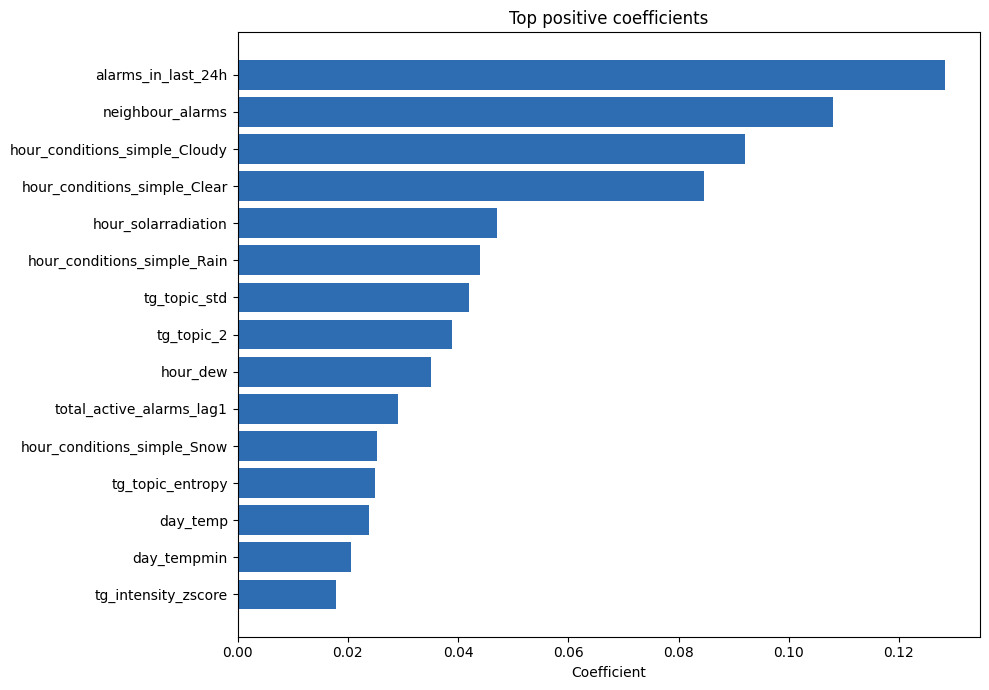

In [14]:
plt.figure(figsize=(10, 7))
plt.barh(positive["feature"], positive["coefficient"], color=BLUE_MAIN)
plt.xlabel("Coefficient")
plt.title("Top positive coefficients")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

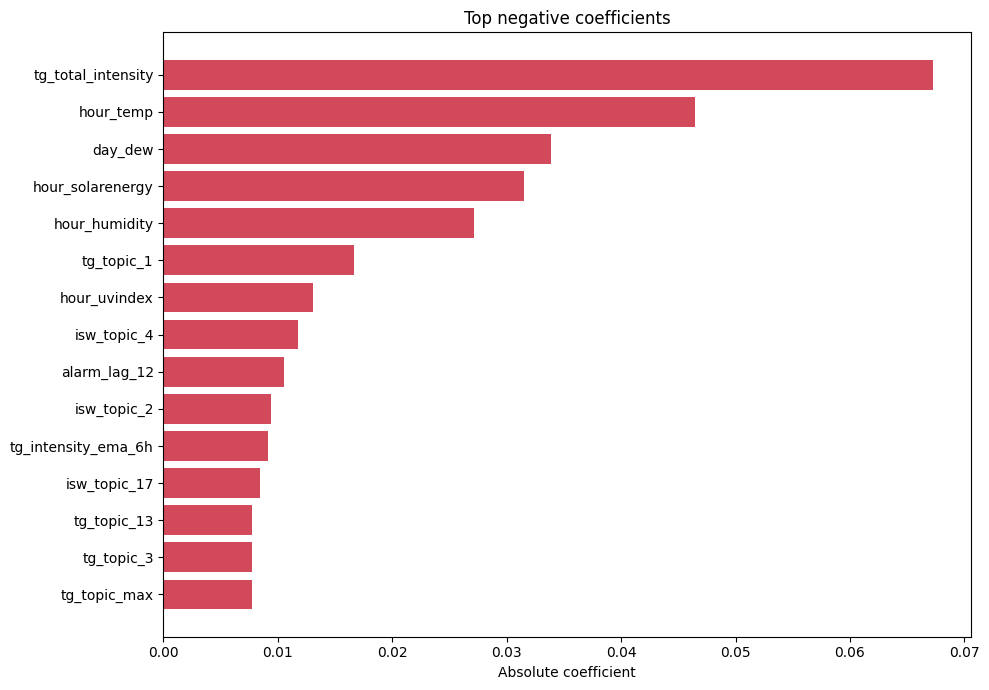

In [15]:
plt.figure(figsize=(10, 7))
plt.barh(negative["feature"], negative["coefficient"].abs(), color=RED_ACCENT)
plt.xlabel("Absolute coefficient")
plt.title("Top negative coefficients")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()